In [ ]:
!pip install pycaret

### Python Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pycaret

## 1- Preparación de datos


In [6]:
from pycaret.datasets import get_data
dataset = get_data('ObesityDataSet')

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [7]:
dataset.shape #tamaño del dataset

(2111, 17)

In [8]:
## sample devuelve una muestra aleatoria de un eje del objeto, serian 2005 no 2111
data = dataset.sample(frac=0.95, random_state=786)

In [9]:
# variable que guardara el arreglo de datos que se usaran para el 70/30
# (70 % para para entrenamiento y 30% para prueba)
data

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
461,Male,21.000000,1.710000,100.000000,yes,yes,2.000000,1.000000,Sometimes,no,2.000000,no,0.000000,2.000000,no,Public_Transportation,Obesity_Type_I
1838,Female,20.989016,1.807340,155.872093,yes,yes,3.000000,3.000000,Sometimes,no,2.417122,no,0.952725,0.573958,Sometimes,Public_Transportation,Obesity_Type_III
1595,Male,24.443011,1.873368,121.829620,yes,yes,2.722161,2.658837,Sometimes,no,2.375707,no,1.299469,0.000000,Sometimes,Public_Transportation,Obesity_Type_II
1821,Female,20.590046,1.736276,130.927138,yes,yes,3.000000,3.000000,Sometimes,no,1.852692,no,1.463610,0.962336,Sometimes,Public_Transportation,Obesity_Type_III
932,Male,22.828435,1.710415,75.142858,yes,yes,2.786008,3.000000,Sometimes,no,2.526193,no,0.925118,2.000000,Sometimes,Public_Transportation,Overweight_Level_I
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2063,Female,20.952737,1.730333,132.116491,yes,yes,3.000000,3.000000,Sometimes,no,1.674061,no,1.683497,0.780199,Sometimes,Public_Transportation,Obesity_Type_III
1793,Male,30.715160,1.650189,101.141277,yes,yes,2.913452,2.269799,Sometimes,no,1.000000,no,1.889937,0.378818,no,Public_Transportation,Obesity_Type_II
1038,Female,34.389679,1.691322,77.561602,yes,yes,3.000000,1.802305,Sometimes,no,2.000000,no,0.390877,0.000000,no,Automobile,Overweight_Level_II
643,Male,19.962470,1.756338,54.982340,yes,yes,2.277436,3.502604,Sometimes,no,2.891713,no,1.696294,1.894902,no,Public_Transportation,Insufficient_Weight


In [10]:
# apartados ya los datos  que seran usados para entrenar y prueba
# guardamos en otra variable para predicciones futuras, en total serian 106 (%5)
data_unseen = dataset.drop(data.index)

In [11]:
data_unseen # variable que guardara el arreglo de datos que no se usaran en el modelo (datos de validacion)

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
5,Male,29.000000,1.620000,53.000000,no,yes,2.0,3.0,Sometimes,no,2.000000,no,0.000000,0.000000,Sometimes,Automobile,Normal_Weight
7,Male,22.000000,1.640000,53.000000,no,no,2.0,3.0,Sometimes,no,2.000000,no,3.000000,0.000000,Sometimes,Public_Transportation,Normal_Weight
13,Male,41.000000,1.800000,99.000000,no,yes,2.0,3.0,Sometimes,no,2.000000,no,2.000000,1.000000,Frequently,Automobile,Obesity_Type_I
17,Female,29.000000,1.530000,78.000000,no,yes,2.0,1.0,Sometimes,no,2.000000,no,0.000000,0.000000,no,Automobile,Obesity_Type_I
33,Male,39.000000,1.790000,90.000000,no,no,2.0,1.0,Sometimes,no,2.000000,no,0.000000,0.000000,Sometimes,Public_Transportation,Overweight_Level_II
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1968,Female,25.909353,1.644078,102.277765,yes,yes,3.0,3.0,Sometimes,no,1.029241,no,0.075776,1.000000,Sometimes,Public_Transportation,Obesity_Type_III
1982,Female,25.524336,1.668931,104.768318,yes,yes,3.0,3.0,Sometimes,no,1.436616,no,0.167086,0.764717,Sometimes,Public_Transportation,Obesity_Type_III
2033,Female,26.000000,1.643017,111.720238,yes,yes,3.0,3.0,Sometimes,no,2.632498,no,0.000000,0.140792,Sometimes,Public_Transportation,Obesity_Type_III
2089,Female,26.000000,1.633887,111.878132,yes,yes,3.0,3.0,Sometimes,no,2.621976,no,0.000000,0.123861,Sometimes,Public_Transportation,Obesity_Type_III


### Division de los datos

In [12]:
## restablecemos el índice de ambos conjuntos de datos
data.reset_index(inplace=True, drop=True)
data_unseen.reset_index(inplace=True, drop=True)
print('Data for Modeling: ' + str(data.shape))
print('Unseen Data For Predictions: ' + str(data_unseen.shape))

Data for Modeling: (2005, 17)
Unseen Data For Predictions: (106, 17)


## 2 - Configurar el entorno de PyCaret

In [13]:
from pycaret.classification import * #configuracion del entorno

In [ ]:
%pip install preprocessing

In [14]:
model_setup = setup(data=data, target='NObeyesdad', session_id=123)

,Description,Value
0,Session id,123
1,Target,NObeyesdad
2,Target type,Multiclass
3,Target mapping,"Insufficient_Weight: 0, Normal_Weight: 1, Obesity_Type_I: 2, Obesity_Type_II: 3, Obesity_Type_III: 4, Overweight_Level_I: 5, Overweight_Level_II: 6"
4,Original data shape,"(2005, 17)"
5,Transformed data shape,"(2005, 26)"
6,Transformed train set shape,"(1403, 26)"
7,Transformed test set shape,"(602, 26)"
8,Numeric features,8
9,Categorical features,8


### Comparacion entre los modelos

La salida imprime una cuadrícula de puntuación que muestra el promedio de la Exactitud, AUC, Recall, Precisión, F1, Kappa, y MCC a través de los pliegues (10 por defecto) junto con los tiempos de entrenamiento.

In [ ]:
models()

In [15]:
best_model = compare_models()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.9651,0.9979,0.9651,0.9674,0.9651,0.9592,0.9596,5.2500
xgboost,Extreme Gradient Boosting,0.9629,0.9976,0.9629,0.9649,0.9629,0.9567,0.9570,0.7030
gbc,Gradient Boosting Classifier,0.9501,0.0000,0.9501,0.9526,0.9499,0.9417,0.9421,2.5940
rf,Random Forest Classifier,0.9451,0.9954,0.9451,0.9497,0.9456,0.9359,0.9365,0.4020
dt,Decision Tree Classifier,0.9387,0.9644,0.9387,0.9418,0.9384,0.9284,0.9290,0.2240
et,Extra Trees Classifier,0.9216,0.9920,0.9216,0.9266,0.9220,0.9083,0.9091,0.5040
lda,Linear Discriminant Analysis,0.8952,0.0000,0.8952,0.8993,0.8937,0.8776,0.8787,0.2240
knn,K Neighbors Classifier,0.8567,0.9705,0.8567,0.8600,0.8488,0.8326,0.8354,0.1370
lr,Logistic Regression,0.8168,0.0000,0.8168,0.8189,0.8118,0.7859,0.7877,1.6470
ridge,Ridge Classifier,0.6379,0.0000,0.6379,0.6451,0.6029,0.5768,0.5878,0.1240


Processing:   0%|          | 0/65 [00:00<?, ?it/s]

### Instanciamiento de Regresion Logistica



*   Regresion Logistica ( Lr )



In [16]:
lr = create_model('lr') #el objeto del modelo entrenado se almacena en la variable 'lr'

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8440,0.0000,0.8440,0.8436,0.8415,0.8179,0.8187
1,0.8085,0.0000,0.8085,0.8124,0.8015,0.7763,0.7785
2,0.8298,0.0000,0.8298,0.8271,0.8236,0.8011,0.8024
3,0.8143,0.0000,0.8143,0.8124,0.8081,0.7832,0.7849
4,0.8000,0.0000,0.8000,0.7995,0.7938,0.7660,0.7678
5,0.8143,0.0000,0.8143,0.8146,0.8114,0.7828,0.7839
6,0.8143,0.0000,0.8143,0.8217,0.8122,0.7829,0.7847
7,0.8071,0.0000,0.8071,0.8072,0.7988,0.7746,0.7767
8,0.8429,0.0000,0.8429,0.8622,0.8425,0.8166,0.8199


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

In [17]:
print(lr)

LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=1000,
                   multi_class='auto', n_jobs=None, penalty='l2',
                   random_state=123, solver='lbfgs', tol=0.0001, verbose=0,
                   warm_start=False)


### Ajuste de la regresion logistica

In [18]:
# usamos la funcion tune_model() para ajustar los hiperparametros automaticamente
# La salida imprime una tabla de puntuación que muestra
# la exactitud, AUC, Recall, Precisión, F1, Kappa y MCC por pliegue
tuned_lr = tune_model(lr)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8298,0.0000,0.8298,0.8281,0.8263,0.8012,0.8020
1,0.8723,0.0000,0.8723,0.8722,0.8697,0.8508,0.8516
2,0.8652,0.0000,0.8652,0.8678,0.8620,0.8425,0.8439
3,0.8429,0.0000,0.8429,0.8492,0.8393,0.8166,0.8185
4,0.7929,0.0000,0.7929,0.7898,0.7860,0.7575,0.7593
5,0.8429,0.0000,0.8429,0.8463,0.8393,0.8162,0.8180
6,0.8929,0.0000,0.8929,0.8935,0.8926,0.8747,0.8749
7,0.8571,0.0000,0.8571,0.8605,0.8531,0.8331,0.8348
8,0.8714,0.0000,0.8714,0.8899,0.8735,0.8499,0.8525


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 10 folds for each of 10 candidates, totalling 100 fits


obtenemos un aumento en la metrica de promedio de precision, pasando de un 0.8168 a un 0.8496

In [19]:
print(tuned_lr) ## Modelo ajustado

LogisticRegression(C=7.689, class_weight={}, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=1000,
                   multi_class='auto', n_jobs=None, penalty='l2',
                   random_state=123, solver='lbfgs', tol=0.0001, verbose=0,
                   warm_start=False)


si comparamos el modelo original, con el modelo ajustado, existe una diferencia en el parámetro de regularización C, que aumentó de 1.0 a 7.689, indicando una menor fuerza de regularización en el modelo ajustado


---

Matricas a evaluar
*   Recall
*   F1
*   Accuracy









## 3 - Graficando el modelo

### Grafico AUC

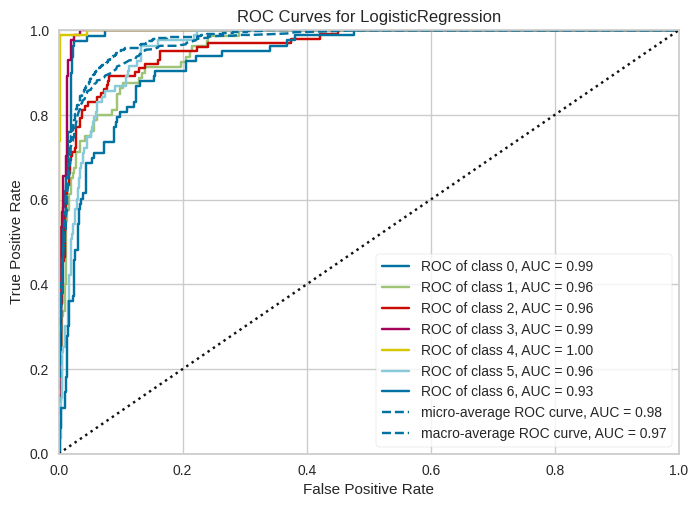

In [22]:
# usamos plot_model para analizar el rendimiento a través de diferentes aspectos
plot_model(tuned_lr, plot = 'auc')

### Grafico Curva de precision-recall

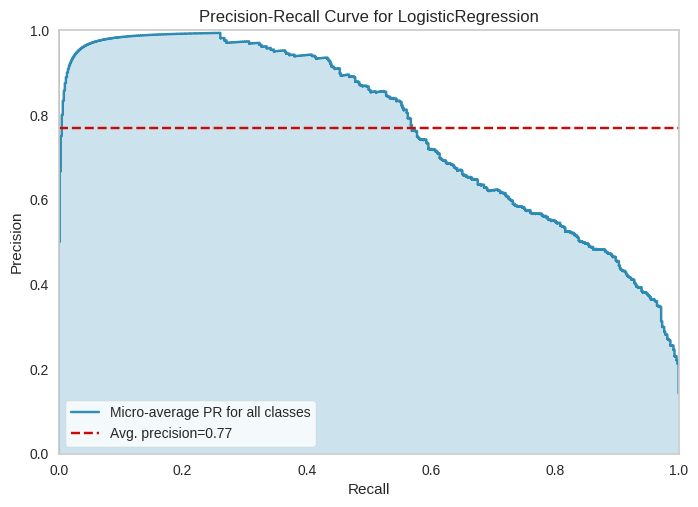

In [23]:
plot_model(tuned_lr, plot = 'pr')

### Matriz de confusion

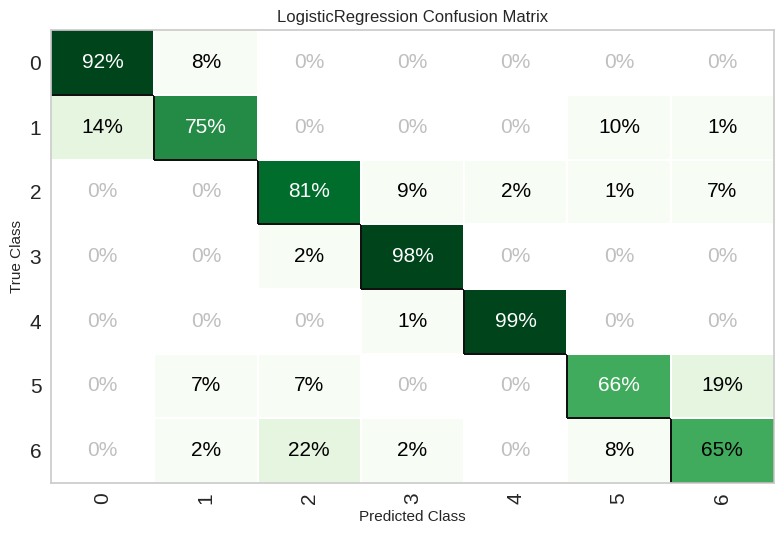

In [24]:
plot_model(tuned_lr, plot = 'confusion_matrix', plot_kwargs={'percent': True})

### Grafico Caracteristicas importantes

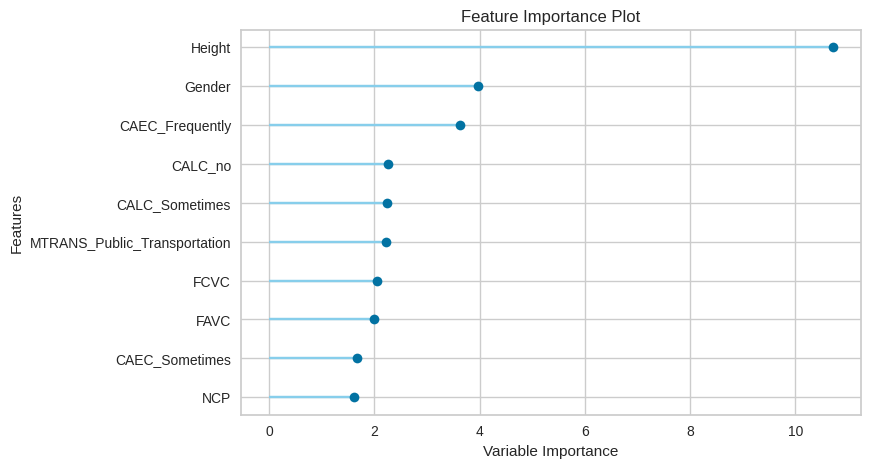

In [25]:
plot_model(tuned_lr, plot='feature')

### Graficar el reporte de clasificación

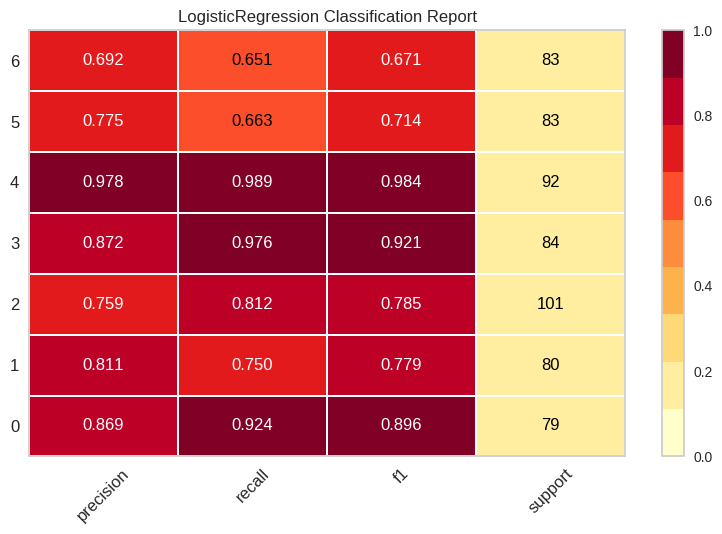

In [26]:
plot_model(tuned_lr, plot = 'class_report')

In [ ]:
# Otra forma de analizar el rendimiento del modelo es utilizar la función evaluate_model()
# que muestra una interfaz de usuario para todos los gráficos disponibles para un modelo determinado.
# Internamente utiliza la función plot_model().
evaluate_model(tuned_lr)

## 4 - Finalizar el modelo

In [27]:
final_lr = finalize_model(tuned_lr)

In [28]:
#Parámetros finales del modelo Regresion Logistica para su despliegue a producción
print(final_lr)

Pipeline(memory=Memory(location=None),
         steps=[('label_encoding',
                 TransformerWrapperWithInverse(exclude=None, include=None,
                                               transformer=LabelEncoder())),
                ('numerical_imputer',
                 TransformerWrapper(exclude=None,
                                    include=['Age', 'Height', 'Weight', 'FCVC',
                                             'NCP', 'CH2O', 'FAF', 'TUE'],
                                    transformer=SimpleImputer(add_indicator=False,
                                                              copy=True,
                                                              fill_value=None,
                                                              keep_empty_...
                                                              handle_missing='return_nan',
                                                              handle_unknown='value',
                                          

## 5 - Prediccion con el modelo

In [29]:
#predecir usando el 30% de los datos para testing
data_see_predictions = predict_model(final_lr, data=data)
data_see_predictions

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Logistic Regression,0.8723,0.9839,0.8723,0.8709,0.8704,0.8508,0.8512


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad,prediction_label,prediction_score
0,Male,21.000000,1.710000,100.000000,yes,yes,2.000000,1.000000,Sometimes,no,2.000000,no,0.000000,2.000000,no,Public_Transportation,Obesity_Type_I,Obesity_Type_I,0.7376
1,Female,20.989016,1.807340,155.872086,yes,yes,3.000000,3.000000,Sometimes,no,2.417122,no,0.952725,0.573958,Sometimes,Public_Transportation,Obesity_Type_III,Obesity_Type_III,0.9990
2,Male,24.443010,1.873368,121.829620,yes,yes,2.722161,2.658837,Sometimes,no,2.375707,no,1.299469,0.000000,Sometimes,Public_Transportation,Obesity_Type_II,Obesity_Type_II,0.9561
3,Female,20.590046,1.736276,130.927139,yes,yes,3.000000,3.000000,Sometimes,no,1.852692,no,1.463610,0.962336,Sometimes,Public_Transportation,Obesity_Type_III,Obesity_Type_III,0.9974
4,Male,22.828436,1.710415,75.142860,yes,yes,2.786008,3.000000,Sometimes,no,2.526193,no,0.925118,2.000000,Sometimes,Public_Transportation,Overweight_Level_I,Overweight_Level_I,0.4853
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2000,Female,20.952738,1.730333,132.116486,yes,yes,3.000000,3.000000,Sometimes,no,1.674061,no,1.683497,0.780199,Sometimes,Public_Transportation,Obesity_Type_III,Obesity_Type_III,0.9929
2001,Male,30.715160,1.650189,101.141273,yes,yes,2.913452,2.269799,Sometimes,no,1.000000,no,1.889937,0.378818,no,Public_Transportation,Obesity_Type_II,Obesity_Type_II,0.9142
2002,Female,34.389679,1.691322,77.561600,yes,yes,3.000000,1.802305,Sometimes,no,2.000000,no,0.390877,0.000000,no,Automobile,Overweight_Level_II,Overweight_Level_II,0.4996
2003,Male,19.962469,1.756338,54.982342,yes,yes,2.277436,3.502604,Sometimes,no,2.891713,no,1.696294,1.894902,no,Public_Transportation,Insufficient_Weight,Insufficient_Weight,0.9478


from matplotlib import pyplot as plt
_df_0['index'].plot(kind='hist', bins=20, title='index')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_1['Age'].plot(kind='hist', bins=20, title='Age')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_2['Height'].plot(kind='hist', bins=20, title='Height')
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
_df_16['Weight'].plot(kind='line', figsize=(8, 4), title='Weight')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_17['prediction_label'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_17, x='index', y='prediction_label', inner='box', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_18['prediction_label'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_18, x='Age', y='prediction_label', inner='box', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_19['prediction_label'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_19, x='Height', y='prediction_label', inner='box', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_20['prediction_label'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_20, x='Weight', y='prediction_label', inner='box', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)


*   prediction_label es la predicción
*   prediction_score es la probabilidad de la predicción

In [30]:
unseen_predictions = predict_model(final_lr, data=data_unseen) #predecir usando el conjunto de datos no vistos
unseen_predictions
# prediction_label es la predicción y prediction_score es la probabilidad de la predicción

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Logistic Regression,0.7736,0.9631,0.7736,0.7973,0.7629,0.7360,0.7429


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad,prediction_label,prediction_score
0,Male,29.000000,1.620000,53.000000,no,yes,2.0,3.0,Sometimes,no,2.000000,no,0.000000,0.000000,Sometimes,Automobile,Normal_Weight,Insufficient_Weight,0.7856
1,Male,22.000000,1.640000,53.000000,no,no,2.0,3.0,Sometimes,no,2.000000,no,3.000000,0.000000,Sometimes,Public_Transportation,Normal_Weight,Normal_Weight,0.5170
2,Male,41.000000,1.800000,99.000000,no,yes,2.0,3.0,Sometimes,no,2.000000,no,2.000000,1.000000,Frequently,Automobile,Obesity_Type_I,Obesity_Type_I,0.4096
3,Female,29.000000,1.530000,78.000000,no,yes,2.0,1.0,Sometimes,no,2.000000,no,0.000000,0.000000,no,Automobile,Obesity_Type_I,Obesity_Type_I,0.8999
4,Male,39.000000,1.790000,90.000000,no,no,2.0,1.0,Sometimes,no,2.000000,no,0.000000,0.000000,Sometimes,Public_Transportation,Overweight_Level_II,Obesity_Type_II,0.8663
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101,Female,25.909353,1.644078,102.277763,yes,yes,3.0,3.0,Sometimes,no,1.029241,no,0.075776,1.000000,Sometimes,Public_Transportation,Obesity_Type_III,Obesity_Type_III,0.8466
102,Female,25.524336,1.668931,104.768318,yes,yes,3.0,3.0,Sometimes,no,1.436616,no,0.167086,0.764717,Sometimes,Public_Transportation,Obesity_Type_III,Obesity_Type_III,0.9408
103,Female,26.000000,1.643017,111.720238,yes,yes,3.0,3.0,Sometimes,no,2.632498,no,0.000000,0.140792,Sometimes,Public_Transportation,Obesity_Type_III,Obesity_Type_III,0.9932
104,Female,26.000000,1.633887,111.878136,yes,yes,3.0,3.0,Sometimes,no,2.621976,no,0.000000,0.123861,Sometimes,Public_Transportation,Obesity_Type_III,Obesity_Type_III,0.9931


como podemos observar, al usar el modelo para predecir teniendo en cuenta los datos que el mismo nunca uso para entrenar y probar. encontramos que metricas como:


1.   Recall
arroja un 0.7736 en la prediccion de los resultados
---
2.   F1
arroja un 0.7629 en la prediccion de los resultados


---
3. Accuracy arroja un 0.7736 en la prediccion de los resultados





In [31]:
save_model(final_lr, './Obesity_LR_Model_13042025_v1')  #Guardas el modelo, en formato pkl

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('label_encoding',
                  TransformerWrapperWithInverse(exclude=None, include=None,
                                                transformer=LabelEncoder())),
                 ('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['Age', 'Height', 'Weight', 'FCVC',
                                              'NCP', 'CH2O', 'FAF', 'TUE'],
                                     transformer=SimpleImputer(add_indicator=False,
                                                               copy=True,
                                                               fill_value=None,
                                                               keep_empty_...
                                                               handle_missing='return_nan',
                                                               handle_unknown='value',
                            

In [32]:
model_v1 = load_model('./Obesity_LR_Model_13042025_v1') #Carga el modelo

Transformation Pipeline and Model Successfully Loaded


In [33]:
new_prediction = predict_model(model_v1, data=data_unseen) #instanciamos una variable para almacenar el modelo cargado
new_prediction

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Logistic Regression,0.7736,0.9631,0.7736,0.7973,0.7629,0.7360,0.7429


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad,prediction_label,prediction_score
0,Male,29.000000,1.620000,53.000000,no,yes,2.0,3.0,Sometimes,no,2.000000,no,0.000000,0.000000,Sometimes,Automobile,Normal_Weight,Insufficient_Weight,0.7856
1,Male,22.000000,1.640000,53.000000,no,no,2.0,3.0,Sometimes,no,2.000000,no,3.000000,0.000000,Sometimes,Public_Transportation,Normal_Weight,Normal_Weight,0.5170
2,Male,41.000000,1.800000,99.000000,no,yes,2.0,3.0,Sometimes,no,2.000000,no,2.000000,1.000000,Frequently,Automobile,Obesity_Type_I,Obesity_Type_I,0.4096
3,Female,29.000000,1.530000,78.000000,no,yes,2.0,1.0,Sometimes,no,2.000000,no,0.000000,0.000000,no,Automobile,Obesity_Type_I,Obesity_Type_I,0.8999
4,Male,39.000000,1.790000,90.000000,no,no,2.0,1.0,Sometimes,no,2.000000,no,0.000000,0.000000,Sometimes,Public_Transportation,Overweight_Level_II,Obesity_Type_II,0.8663
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101,Female,25.909353,1.644078,102.277763,yes,yes,3.0,3.0,Sometimes,no,1.029241,no,0.075776,1.000000,Sometimes,Public_Transportation,Obesity_Type_III,Obesity_Type_III,0.8466
102,Female,25.524336,1.668931,104.768318,yes,yes,3.0,3.0,Sometimes,no,1.436616,no,0.167086,0.764717,Sometimes,Public_Transportation,Obesity_Type_III,Obesity_Type_III,0.9408
103,Female,26.000000,1.643017,111.720238,yes,yes,3.0,3.0,Sometimes,no,2.632498,no,0.000000,0.140792,Sometimes,Public_Transportation,Obesity_Type_III,Obesity_Type_III,0.9932
104,Female,26.000000,1.633887,111.878136,yes,yes,3.0,3.0,Sometimes,no,2.621976,no,0.000000,0.123861,Sometimes,Public_Transportation,Obesity_Type_III,Obesity_Type_III,0.9931
